Best Parameters:
{'svm__C': 20, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
Best Cross-Validation Accuracy:
0.9731
Test Accuracy: 0.9474


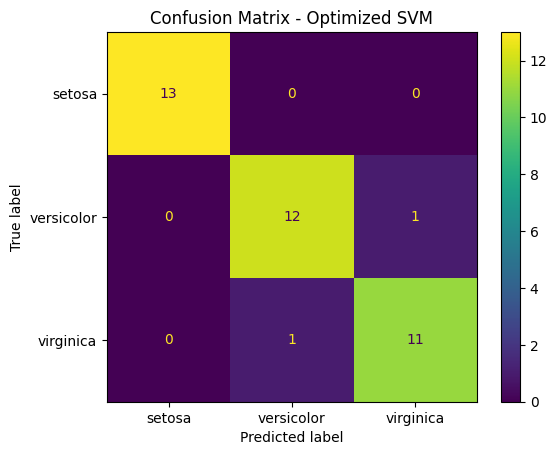

Cross-Validation Scores:
[0.8667 1.     1.     0.9667 0.9   ]
Mean Accuracy: 0.9467
Standard Deviation: 0.0542


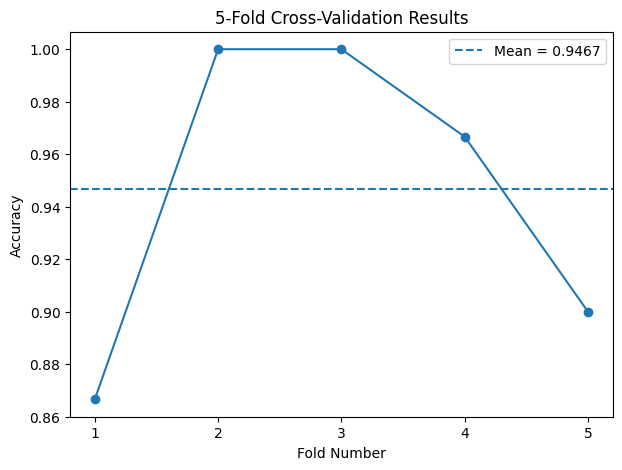

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

data = load_iris()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=7, stratify=y
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC())
])

parameters = {
    "svm__C": [0.5, 1, 5, 20],
    "svm__gamma": ["scale", 0.1, 0.01],
    "svm__kernel": ["rbf", "linear"]
}

search = GridSearchCV(
    pipeline,
    parameters,
    cv=5,
    scoring="accuracy"
)

search.fit(X_train, y_train)

print("Best Parameters:")
print(search.best_params_)

print("Best Cross-Validation Accuracy:")
print(round(search.best_score_, 4))

best_model = search.best_estimator_

predictions = best_model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Test Accuracy:", round(accuracy, 4))

matrix = confusion_matrix(y_test, predictions)

ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=data.target_names
).plot()

plt.title("Confusion Matrix - Optimized SVM")
plt.show()

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=7
)

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=kf,
    scoring="accuracy"
)

print("Cross-Validation Scores:")
print(np.round(scores, 4))

mean_score = scores.mean()
std_score = scores.std()

print("Mean Accuracy:", round(mean_score, 4))
print("Standard Deviation:", round(std_score, 4))

plt.figure(figsize=(7, 5))
plt.plot(
    range(1, 6),
    scores,
    marker="o"
)
plt.axhline(
    mean_score,
    linestyle="--",
    label=f"Mean = {mean_score:.4f}"
)
plt.xticks(range(1, 6))
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross-Validation Results")
plt.legend()
plt.show()